<center><font size=6>ShopClues Men's Clothing — Web Scraping & Business Analysis </center></font>
<center><img src="https://colaninfotech.com/wp-content/uploads/2024/07/web-scraping.14c36f6b.jpg" width="720"/></center>

<center>Web Scraping • Data Cleaning • EDA • SQL Analysis • Business Insights</center>

# Project Overview


- Online clothing websites contain useful product information such as price, discount, rating and shipping. This information can help a business understand pricing, promotions and product performance.

# Objective

- build an end-to-end pipeline that scrapes ShopClues men's clothing products, cleans the data, explores it, and answers business questions using SQL.

**Workflow:** `Scraping → Cleaning → EDA → Visualization → SQL → Validation → Business Insights`

The pipeline:
- Collects 400+ unique products using the ShopClues AJAX endpoint
- Extracts product details (name, price, discount, rating, shipping, URL, image)
- Cleans and standardizes the scraped data
- Explores price, discount and rating patterns
- Answers business questions using SQL
- Summarizes findings into business recommendations

# Data Collection



* Imports the required libraries.
* Reproduces the ShopClues `moreProducts` AJAX request found in DevTools.
* Creates a session and tests the request before scraping at scale.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import sqlite3
import re
import time
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


#### AJAX Request



* ShopClues loads more products through an AJAX endpoint: `ajaxCall/moreProducts`.
* Key parameters (`catId`, `page`, `start`, etc.) were identified from the Network tab.
* Using `requests` to call this endpoint directly avoids the need for Selenium.

In [2]:
ajax_url = "https://www.shopclues.com/ajaxCall/moreProducts"

base_params = {
    "catId": "139",
    "filters": "",
    "pageType": "c",
    "columns": "3",
    "fl_cal": "1",
    "url_link": "https://www.shopclues.com/mens-clothing",
    "DM_TEXT": "",
    "sc_z": "",
    "tile": "3",
    "user_id": "",
    "user_segment": "default"
}

print("AJAX URL:")
print(ajax_url)

print("\nParameters:")
print(base_params)

AJAX URL:
https://www.shopclues.com/ajaxCall/moreProducts

Parameters:
{'catId': '139', 'filters': '', 'pageType': 'c', 'columns': '3', 'fl_cal': '1', 'url_link': 'https://www.shopclues.com/mens-clothing', 'DM_TEXT': '', 'sc_z': '', 'tile': '3', 'user_id': '', 'user_segment': 'default'}


#### Session Setup



* A `requests.Session()` keeps cookies consistent across requests.
* The men's clothing page is visited first so later AJAX calls look like normal browser activity.

In [3]:
session = requests.Session()

headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.shopclues.com/mens-clothing.html",
    "X-Requested-With": "XMLHttpRequest"
}

page_url = "https://www.shopclues.com/mens-clothing.html"

page_response = session.get(
    page_url,
    headers=headers,
    timeout=30
)

print("Status code:", page_response.status_code)
print("Session created successfully!")

Status code: 200
Session created successfully!


#### Test Request



* Sends one AJAX request using the parameters found in DevTools.
* Confirms a `200` status and valid HTML before scraping all pages.

In [4]:
test_params = base_params.copy()

test_params["page"] = "18"
test_params["start"] = "168"

response = session.get(
    ajax_url,
    params=test_params,
    headers=headers,
    timeout=30
)

print("Status code:", response.status_code)
print("Response length:", len(response.text))
print("\nFirst 1000 characters:")
print(response.text[:1000])

Status code: 200
Response length: 102335

First 1000 characters:
                      <span class="pagination">
                      <link href="https://www.shopclues.com/mens-clothing.html?page=17" rel="prev">
                                          <link href="https://www.shopclues.com/mens-clothing.html?page=19" rel="next">
                                        </span>
                                        <div class="row">
                                          
                        <div class="column col4">
                            <a class="whishlist_ic" pid ="153635897" href="javascript:void(0);"></a>
                            <a href="//www.shopclues.com/print-cultr-print-cultr-men-printed-single-breasted-casual-blazer-black-153635897.html" target="_blank">
                                                            <div class="img_section img_320new">
                                                                                                            

### Product Extraction



* Locates product cards in the HTML response and extracts details for each product.
* Uses product IDs to avoid collecting duplicates.

#### Product Cards



* Product cards are identified using the `a[pid]` selector, where `pid` is the product ID.

In [5]:
soup = BeautifulSoup(response.text, "lxml")

product_links = soup.select("a[pid]")

print("Product elements found:", len(product_links))

Product elements found: 24


* Each `a[pid]` element sits inside a parent `div` that holds the full product card (name, price, discount, shipping, image, URL).

In [6]:
def get_product_card(product_link):
    # Find the parent div that contains the complete card
    card = product_link.find_parent("div", class_="column")

    return card


first_link = product_links[0]

first_card = get_product_card(first_link)

print(first_card.prettify()[:3000])

<div class="column col4">
 <a class="whishlist_ic" href="javascript:void(0);" pid="153635897">
 </a>
 <a href="//www.shopclues.com/print-cultr-print-cultr-men-printed-single-breasted-casual-blazer-black-153635897.html" target="_blank">
  <div class="img_section img_320new">
   <img alt="PrintCultr PrintCultr Men Printed Single Breasted Casual Blazer (Black)" border="0" class="" data-img="https://cdn2.shopclues.com/images1/thumbnails/118033/320/320/153635897-118033090-1737271777.jpg" id="det_img_153635897" src="https://cdn2.shopclues.com/images1/thumbnails/118033/320/320/153635897-118033090-1737271777.jpg" title="PrintCultr PrintCultr Men Printed Single Breasted Casual Blazer (Black)"/>
  </div>
  <div class="extraBadges">
  </div>
  <span class="prod_name">
   PrintCultr PrintCultr Men Printed Single Breasted Casua
  </span>
  <div class="prd_p_section new_prd_section">
   <div class="ori_price">
    <span class="p_price">
     ₹1,249
    </span>
    <span class="old_prices">
     <!--

#### Duplicate Handling



* Stores products in a dictionary keyed by `product_id`, so repeated IDs are automatically ignored.

In [7]:
unique_products = {}

for product_link in product_links:

    product_id = product_link.get("pid")

    card = get_product_card(product_link)

    if product_id and card:

        if product_id not in unique_products:

            unique_products[product_id] = {
                "product_id": product_id,
                "html": str(card)
            }

print("Unique products:", len(unique_products))

Unique products: 24


#### Collecting 400+ Products



* Pagination is driven by `page` and `start`, increasing by 1 and 24 respectively per request.
* Target is set to 400+ unique products.

In [8]:
target_products = 400

page = 19
start = 192

page_step = 1
start_step = 24

maximum_requests = 40

print("Target:", target_products)
print("Starting page:", page)
print("Starting start value:", start)

Target: 400
Starting page: 19
Starting start value: 192


* Sends repeated AJAX requests, increasing `page`/`start` each time.
* Extracts product cards from every response and adds only new product IDs.
* Stops once 400+ unique products are collected, a request fails, or no new products are found.

In [9]:
for number in range(maximum_requests):

    # Stop if we already have enough products
    if len(unique_products) >= target_products:
        print("We reached 400+ products!")
        break

    # Make a copy of our parameters
    params = base_params.copy()

    # Change page and start
    params["page"] = str(page)
    params["start"] = str(start)

    # Send request
    response = session.get(
        ajax_url,
        params=params,
        headers=headers,
        timeout=30
    )

    print("\nRequest number:", number + 1)
    print("Page:", page)
    print("Start:", start)
    print("Status:", response.status_code)

    # Check whether request worked
    if response.status_code != 200:
        print("Request failed. Stopping.")
        break

    # Read the HTML
    soup = BeautifulSoup(response.text, "lxml")

    # Find product links
    product_links = soup.select("a[pid]")

    print("Cards found:", len(product_links))

    new_products = 0

    # Go through every product
    for product_link in product_links:

        product_id = product_link.get("pid")

        card = get_product_card(product_link)

        if product_id and card:

            # Only add if we have not seen this ID before
            if product_id not in unique_products:

                unique_products[product_id] = {
                    "product_id": product_id,
                    "html": str(card)
                }

                new_products = new_products + 1

    print("New products:", new_products)
    print("Total unique products:", len(unique_products))

    # If nothing new was found, stop
    if new_products == 0:
        print("No new products found. Check pagination.")
        break

    # Move to next page
    page = page + page_step
    start = start + start_step

    # Small delay
    time.sleep(1.5)

print("\nScraping finished!")
print("Total unique products:", len(unique_products))


Request number: 1
Page: 19
Start: 192
Status: 200
Cards found: 24
New products: 24
Total unique products: 48

Request number: 2
Page: 20
Start: 216
Status: 200
Cards found: 24
New products: 24
Total unique products: 72

Request number: 3
Page: 21
Start: 240
Status: 200
Cards found: 24
New products: 24
Total unique products: 96

Request number: 4
Page: 22
Start: 264
Status: 200
Cards found: 24
New products: 24
Total unique products: 120

Request number: 5
Page: 23
Start: 288
Status: 200
Cards found: 24
New products: 24
Total unique products: 144

Request number: 6
Page: 24
Start: 312
Status: 200
Cards found: 24
New products: 24
Total unique products: 168

Request number: 7
Page: 25
Start: 336
Status: 200
Cards found: 24
New products: 24
Total unique products: 192

Request number: 8
Page: 26
Start: 360
Status: 200
Cards found: 24
New products: 24
Total unique products: 216

Request number: 9
Page: 27
Start: 384
Status: 200
Cards found: 24
New products: 24
Total unique products: 240

Req

* Confirms enough unique products were collected across all requests before moving to extraction.

In [10]:
all_ids = list(unique_products.keys())

print("Total IDs:", len(all_ids))
print("Unique IDs:", len(set(all_ids)))

if len(all_ids) == len(set(all_ids)):
    print("No duplicate IDs found!")
else:
    print("Duplicate IDs exist.")

Total IDs: 408
Unique IDs: 408
No duplicate IDs found!


#### Product Information



* Inspects one product card's HTML to identify the CSS selectors for name, price, discount, rating, shipping, URL and image.
* Selectors are tested on a single product before writing the extraction function.

In [11]:
first_product_id = list(unique_products.keys())[0]

first_html = unique_products[first_product_id]["html"]

print("Product ID:", first_product_id)
print(first_html[:5000])

Product ID: 153635897
<div class="column col4">
<a class="whishlist_ic" href="javascript:void(0);" pid="153635897"></a>
<a href="//www.shopclues.com/print-cultr-print-cultr-men-printed-single-breasted-casual-blazer-black-153635897.html" target="_blank">
<div class="img_section img_320new">
<img alt="PrintCultr PrintCultr Men Printed Single Breasted Casual Blazer (Black)" border="0" class="" data-img="https://cdn2.shopclues.com/images1/thumbnails/118033/320/320/153635897-118033090-1737271777.jpg" id="det_img_153635897" src="https://cdn2.shopclues.com/images1/thumbnails/118033/320/320/153635897-118033090-1737271777.jpg" title="PrintCultr PrintCultr Men Printed Single Breasted Casual Blazer (Black)"/>
</div>
<div class="extraBadges">
</div>
<span class="prod_name">PrintCultr PrintCultr Men Printed Single Breasted Casua</span>
<div class="prd_p_section new_prd_section">
<div class="ori_price">
<span class="p_price">₹1,249                                    </span>
<span class="old_prices">

In [12]:
soup = BeautifulSoup(first_html, "lxml")

name = soup.select_one(".prod_name")
price = soup.select_one(".p_price")
old_price = soup.select_one(".old_prices")
discount = soup.select_one(".prd_discount")
rating = soup.select_one(".rtnrew .star span")
shipping = soup.select_one(".shipping")
link = soup.select_one("a[href]")
image = soup.select_one("img")

print("Product ID:", first_product_id)

if name:
    print("Name:", name.get_text(" ", strip=True))
else:
    print("Name: Not found")

if price:
    print("Price:", price.get_text(" ", strip=True))
else:
    print("Price: Not found")

if old_price:
    print("Old Price:", old_price.get_text(" ", strip=True))
else:
    print("Old Price: Not found")

if discount:
    print("Discount:", discount.get_text(" ", strip=True))
else:
    print("Discount: Not found")

if rating:
    print("Rating style:", rating.get("style"))
else:
    print("Rating: Not found")

if shipping:
    print("Shipping:", shipping.get_text(" ", strip=True))
else:
    print("Shipping: Not found")

if link:
    print("URL:", link.get("href"))
else:
    print("URL: Not found")

if image:
    print("Image:", image.get("data-img") or image.get("src"))
else:
    print("Image: Not found")

Product ID: 153635897
Name: PrintCultr PrintCultr Men Printed Single Breasted Casua
Price: ₹1,249
Old Price: ₹5,149
Discount: 76% Off
Rating: Not found
Shipping: Free Shipping
URL: javascript:void(0);
Image: https://cdn2.shopclues.com/images1/thumbnails/118033/320/320/153635897-118033090-1737271777.jpg


#### Extraction Function



* `make_short_name()` removes gender words (e.g. "men's") and shortens long product names.
* `extract_product()` pulls name, price, discount, rating, shipping, URL and image from a product card.
* Rating is parsed from the width of a star-rating style attribute and converted to a 0–5 scale.

In [13]:
def make_short_name(name):

    if name is None:
        return None

    # Remove common words that are not very useful in the final name
    words_to_remove = [
        "for men",
        "for men's",
        "for women",
        "for women's",
        "men's",
        "women's",
        "mens",
        "womens"
    ]

    for word in words_to_remove:
        name = re.sub(word, "", name, flags=re.IGNORECASE)

    # Remove extra spaces
    name = re.sub(r"\s+", " ", name).strip()

    # Keep the name short
    words = name.split()

    if len(words) > 8:
        name = " ".join(words[:8])

    return name


def extract_product(product_id, html):

    soup = BeautifulSoup(html, "lxml")

    # Product name
    name = soup.select_one(".prod_name")

    if name:
        name = name.get_text(" ", strip=True)
        name = make_short_name(name)

    # Current price
    price = soup.select_one(".p_price")

    if price:
        price = price.get_text(" ", strip=True)

    # Original price
    old_price = soup.select_one(".old_prices")

    if old_price:
        old_price = old_price.get_text(" ", strip=True)

    # Discount
    discount = soup.select_one(".prd_discount")

    if discount:
        discount = discount.get_text(" ", strip=True)

    # Rating
    rating = None

    rating_span = soup.select_one(".rtnrew .star span")

    if rating_span:
        style = rating_span.get("style", "")

        number = re.search(r"([0-9]+(?:\.[0-9]+)?)", style)

        if number:
            width = float(number.group(1))
            rating = round((width / 100) * 5, 2)

    # Shipping
    shipping = soup.select_one(".shipping")

    if shipping:
        shipping = shipping.get_text(" ", strip=True)

    # Product URL
    link = soup.select_one("a[href]")

    if link:
        link = link.get("href")

    # Image URL
    image = soup.select_one("img")

    if image:
        image = image.get("data-img") or image.get("src")

    product = {
        "product_id": product_id,
        "product_name": name,
        "price_raw": price,
        "original_price_raw": old_price,
        "discount_raw": discount,
        "rating": rating,
        "shipping": shipping,
        "product_url": link,
        "image_url": image
    }

    return product


# Test one product
test_product = extract_product(first_product_id, first_html)

print(test_product)

{'product_id': '153635897', 'product_name': 'PrintCultr PrintCultr Men Printed Single Breasted Casua', 'price_raw': '₹1,249', 'original_price_raw': '₹5,149', 'discount_raw': '76% Off', 'rating': None, 'shipping': 'Free Shipping', 'product_url': 'javascript:void(0);', 'image_url': 'https://cdn2.shopclues.com/images1/thumbnails/118033/320/320/153635897-118033090-1737271777.jpg'}


* Applies `extract_product()` to every scraped product card.

In [14]:
products = []

for product_id in unique_products:

    html = unique_products[product_id]["html"]

    product = extract_product(
        product_id,
        html
    )

    products.append(product)

print("Products extracted:", len(products))

Products extracted: 408


* Converts the list of extracted product dictionaries into a pandas DataFrame.

In [15]:
df = pd.DataFrame(products)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 408
Columns: 9


,product_id,product_name,price_raw,original_price_raw,discount_raw,rating,shipping,product_url,image_url
0,153635897,PrintCultr PrintCultr Men Printed Single Breas...,"₹1,249","₹5,149",76% Off,NaN,Free Shipping,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
1,153636077,PrintCulture Men Solid Black Cotton Blend Nehr...,₹619,"₹5,649",89% Off,NaN,Free Shipping,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
2,153636095,PrintCulture Men Solid Grey Cotton Blend Nehru...,₹619,"₹2,849",78% Off,NaN,Free Shipping,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
3,153636131,PrintCulture Men Solid Black Cotton Blend Nehr...,₹619,"₹5,649",89% Off,NaN,Free Shipping,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
4,153637892,PrintCultr Men Kurta and Pyjama Set (White),₹409,"₹2,350",83% Off,2.24,Free Shipping,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...


In [16]:
print(df.columns.tolist())

['product_id', 'product_name', 'price_raw', 'original_price_raw', 'discount_raw', 'rating', 'shipping', 'product_url', 'image_url']


# Data Cleaning



* Checks for missing values and duplicates.
* Converts price, discount and URL text fields into clean, analysis-ready formats.

In [17]:
print(df.isna().sum())

product_id              0
product_name            0
price_raw               0
original_price_raw      0
discount_raw            0
rating                379
shipping               54
product_url             0
image_url               0
dtype: int64


#### Duplicate Check



* Re-confirms there are no duplicate product IDs after building the DataFrame.

In [18]:
print("Total rows:", len(df))
print("Unique product IDs:", df["product_id"].nunique())
print("Duplicate product IDs:", df["product_id"].duplicated().sum())

Total rows: 408
Unique product IDs: 408
Duplicate product IDs: 0


#### Price Cleaning



* Removes the `₹` symbol and commas from price text, and converts it to a number.

In [19]:
def clean_price(price):

    if pd.isna(price):
        return None

    price = str(price)

    price = price.replace("₹", "")
    price = price.replace(",", "")
    price = price.strip()

    number = re.search(r"\d+(?:\.\d+)?", price)

    if number:
        return float(number.group())

    return None


df["price"] = df["price_raw"].apply(clean_price)

df["original_price"] = df["original_price_raw"].apply(
    clean_price
)

df[[
    "product_name",
    "price_raw",
    "price",
    "original_price_raw",
    "original_price"
]].head(10)

,product_name,price_raw,price,original_price_raw,original_price
0,PrintCultr PrintCultr Men Printed Single Breas...,"₹1,249",1249.0,"₹5,149",5149.0
1,PrintCulture Men Solid Black Cotton Blend Nehr...,₹619,619.0,"₹5,649",5649.0
2,PrintCulture Men Solid Grey Cotton Blend Nehru...,₹619,619.0,"₹2,849",2849.0
3,PrintCulture Men Solid Black Cotton Blend Nehr...,₹619,619.0,"₹5,649",5649.0
4,PrintCultr Men Kurta and Pyjama Set (White),₹409,409.0,"₹2,350",2350.0
5,Manlino Premium Plain Track Pant,₹449,449.0,"₹1,099",1099.0
6,DISONE Beige Silk Dhoti,₹699,699.0,"₹1,999",1999.0
7,Russel Mania Men Vest,₹999,999.0,,NaN
8,PrintCultr Men Purple Cotton Blend Kurta Pyjam...,₹419,419.0,"₹2,350",2350.0
9,PrintCultr Solid Mandarin Festive & Wedding Me...,"₹1,249",1249.0,"₹5,199",5199.0


#### Discount Cleaning



* Extracts the numeric discount percentage from text such as `"60% Off"`.

In [20]:
def clean_discount(discount):

    if pd.isna(discount):
        return None

    discount = str(discount)

    number = re.search(r"\d+(?:\.\d+)?", discount)

    if number:
        return float(number.group())

    return None


df["discount_percent"] = df["discount_raw"].apply(
    clean_discount
)

df[[
    "discount_raw",
    "discount_percent"
]].head(10)

,discount_raw,discount_percent
0,76% Off,76.0
1,89% Off,89.0
2,78% Off,78.0
3,89% Off,89.0
4,83% Off,83.0
5,59% Off,59.0
6,65% Off,65.0
7,,NaN
8,82% Off,82.0
9,76% Off,76.0


#### URL Cleaning



* Adds `https:` to protocol-relative URLs (URLs starting with `//`).

In [21]:
def clean_url(url):

    if pd.isna(url):
        return None

    url = str(url).strip()

    if url.startswith("//"):
        url = "https:" + url

    return url


df["product_url"] = df["product_url"].apply(
    clean_url
)

df["image_url"] = df["image_url"].apply(
    clean_url
)

df[[
    "product_url",
    "image_url"
]].head()

,product_url,image_url
0,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
1,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
2,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
3,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...
4,javascript:void(0);,https://cdn2.shopclues.com/images1/thumbnails/...


#### Missing Value Handling



* Fills missing numeric values (price, original price, discount, rating) with the column average.
* Keeps every scraped product in the dataset instead of dropping incomplete rows.

In [22]:
df["price"] = df["price"].fillna(df["price"].mean())
df["original_price"] = df["original_price"].fillna(
    round(df["original_price"].mean(),2)
)
df["discount_percent"] = df["discount_percent"].fillna(
    df["discount_percent"].mean()
)
df["rating"] = df["rating"].fillna(df["rating"].mean())

print("Missing numeric values:")
print(
    df[
        ["price", "original_price", "discount_percent", "rating"]
    ].isna().sum()
)

print("Average rating:", round(df["rating"].mean(), 2))

Missing numeric values:
price               0
original_price      0
discount_percent    0
rating              0
dtype: int64
Average rating: 1.82


In [23]:
df[[
    "product_id",
    "product_name",
    "price",
    "original_price",
    "discount_percent",
    "rating",
    "shipping"
]].head(10).style.format({
    "price": "{:.2f}",
    "original_price": "{:.2f}",
    "discount_percent": "{:.2f}",
    "rating": "{:.2f}"
})

,product_id,product_name,price,original_price,discount_percent,rating,shipping
0,153635897,PrintCultr PrintCultr Men Printed Single Breasted Casua,1249.00,5149.00,76.00,1.82,Free Shipping
1,153636077,PrintCulture Men Solid Black Cotton Blend Nehru Jacket,619.00,5649.00,89.00,1.82,Free Shipping
2,153636095,PrintCulture Men Solid Grey Cotton Blend Nehru Jacket,619.00,2849.00,78.00,1.82,Free Shipping
3,153636131,PrintCulture Men Solid Black Cotton Blend Nehru Jacket,619.00,5649.00,89.00,1.82,Free Shipping
4,153637892,PrintCultr Men Kurta and Pyjama Set (White),409.00,2350.00,83.00,2.24,Free Shipping
5,143291762,Manlino Premium Plain Track Pant,449.00,1099.00,59.00,1.82,None
6,153158762,DISONE Beige Silk Dhoti,699.00,1999.00,65.00,1.82,None
7,153320861,Russel Mania Men Vest,999.00,4030.01,74.30,1.82,Free Shipping
8,153598769,PrintCultr Men Purple Cotton Blend Kurta Pyjama Set,419.00,2350.00,82.00,1.82,Free Shipping
9,153635697,PrintCultr Solid Mandarin Festive & Wedding Men Blazer,1249.00,5199.00,76.00,1.82,Free Shipping


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          408 non-null    object 
 1   product_name        408 non-null    object 
 2   price_raw           408 non-null    object 
 3   original_price_raw  408 non-null    object 
 4   discount_raw        408 non-null    object 
 5   rating              408 non-null    float64
 6   shipping            354 non-null    object 
 7   product_url         408 non-null    object 
 8   image_url           408 non-null    object 
 9   price               408 non-null    float64
 10  original_price      408 non-null    float64
 11  discount_percent    408 non-null    float64
dtypes: float64(4), object(8)
memory usage: 38.4+ KB


# Exploratory Data Analysis


#### Price Analysis



In [25]:
print("Average price:", round(df["price"].mean(), 2))
print("Median price:", round(df["price"].median(), 2))
print("Lowest price:", df["price"].min())
print("Highest price:", df["price"].max())

Average price: 888.85
Median price: 899.0
Lowest price: 159.0
Highest price: 1899.0


#### Cheapest Products

In [26]:
cheap_products = df.sort_values(
    "price"
)

cheap_products[[
    "product_name",
    "price",
    "discount_percent"
]].head(10)

,product_name,price,discount_percent
256,Stylish Unisex Design Printed Hooded Sweatshir...,159.0,86.0
140,MCS Men Solid Sleeveless White Vest (Pack of,159.0,84.0
67,29K Navy Blue Cotton Fleece Printed Sweatshirt (F,169.0,83.0
257,29K Blue Cotton Fleece Printed Sweatshirt (FDMSWT,189.0,81.0
16,PrintCultr Men Regular Fit Solid Curved Collar...,219.0,85.0
85,PrintCultr Half Sleeve Cotton Spread Collar Shirt,229.0,77.0
124,PrintCultr PLUS Plus Size Men Regular Fit Solid,239.0,84.0
42,white rn vest pack of 3,250.0,17.0
302,Baleshwar Men White Solid Formal Shirt (Pack of,259.0,76.0
170,Baleshwar White Cotton Blend Regular Fit Forma...,279.0,75.0


#### Most Expensive Products

In [27]:
expensive_products = df.sort_values(
    "price",
    ascending=False
)

expensive_products[[
    "product_name",
    "price",
    "discount_percent"
]].head(10)

,product_name,price,discount_percent
403,Regular Fit Blue Jeans,1899.0,74.297872
80,kurta,1699.0,74.297872
386,PrintCultr Printed Mandarin Festive & Wedding ...,1249.0,76.000000
0,PrintCultr PrintCultr Men Printed Single Breas...,1249.0,76.000000
384,PrintCultr PrintCultr Men Solid Single Breaste...,1249.0,76.000000
375,PrintCultr PrintCultr Men Printed Single Breas...,1249.0,76.000000
374,PrintCultr PrintCultr Men Solid Single Breaste...,1249.0,76.000000
385,PrintCultr PrintCultr Men Solid Single Breaste...,1249.0,76.000000
373,PrintCultr Printed Mandarin Festive & Wedding ...,1249.0,76.000000
376,PrintCultr Mandarin Festive & Wedding Men Blaz...,1249.0,76.000000


#### Discount Analysis

In [28]:
highest_discount = df.sort_values(
    "discount_percent",
    ascending=False
)

highest_discount[[
    "product_name",
    "price",
    "discount_percent"
]].head(10)

,product_name,price,discount_percent
253,PrintCulture Men Printed Maroon Cotton Blend N...,619.0,89.0
20,PrintCulture Men Self Design Brown Cotton Blen...,619.0,89.0
18,PrintCulture Men Solid Black Cotton Blend Nehr...,619.0,89.0
17,PrintCulture Men Self Design Multicolor Cotton...,619.0,89.0
227,PrintCulture Men Solid Yellow Cotton Blend Neh...,619.0,89.0
226,PrintCulture Men Printed Black Cotton Blend Ne...,619.0,89.0
225,PrintCulture Men Solid Orange Cotton Blend Neh...,619.0,89.0
224,PrintCulture Men Solid Beige Cotton Blend Nehr...,619.0,89.0
222,PrintCulture Men Solid Red Cotton Blend Nehru ...,619.0,89.0
220,PrintCulture Men Self Design Blue Cotton Blend...,619.0,89.0


#### Shipping Analysis

In [29]:
shipping_count = df["shipping"].fillna(
    "Not Available"
)

print(shipping_count.value_counts())

shipping
Free Shipping    354
Not Available     54
Name: count, dtype: int64


#### Price Distribution



* A histogram shows how prices are spread across ranges.

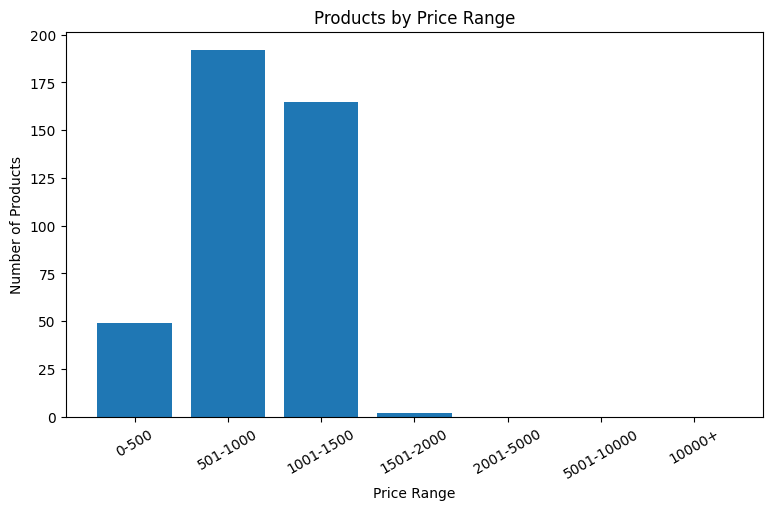

Interpretation:
Shows which price range contains the most products.


In [30]:
# Group products into simple price ranges

price_ranges = pd.cut(
    df["price"],
    bins=[0, 500, 1000, 1500, 2000, 5000, 10000, float("inf")],
    labels=[
        "0-500",
        "501-1000",
        "1001-1500",
        "1501-2000",
        "2001-5000",
        "5001-10000",
        "10000+"
    ]
)

price_count = price_ranges.value_counts().sort_index()

plt.figure(figsize=(9, 5))

plt.bar(
    price_count.index.astype(str),
    price_count.values
)

plt.xlabel("Price Range")
plt.ylabel("Number of Products")
plt.title("Products by Price Range")
plt.xticks(rotation=30)

plt.show()

print("Interpretation:")
print("Shows which price range contains the most products.")

#### Price Spread



* A boxplot highlights the median, spread and outliers in price.

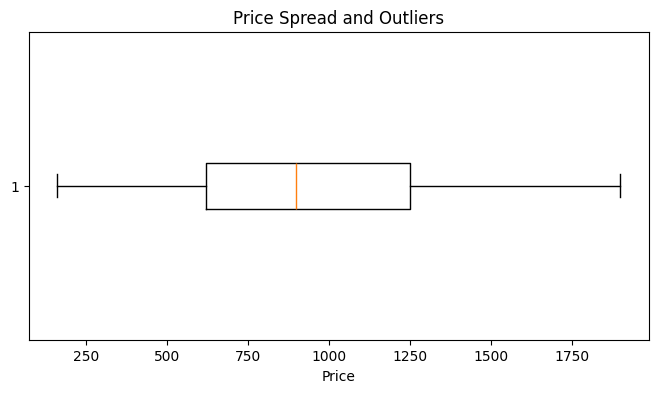

Interpretation:
Shows the typical price range and unusual prices.


In [31]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    df["price"].dropna(),
    vert=False
)

plt.xlabel("Price")
plt.title("Price Spread and Outliers")

plt.show()

print("Interpretation:")
print("Shows the typical price range and unusual prices.")

#### Rating Distribution



* A bar chart shows how products are distributed across rating groups.

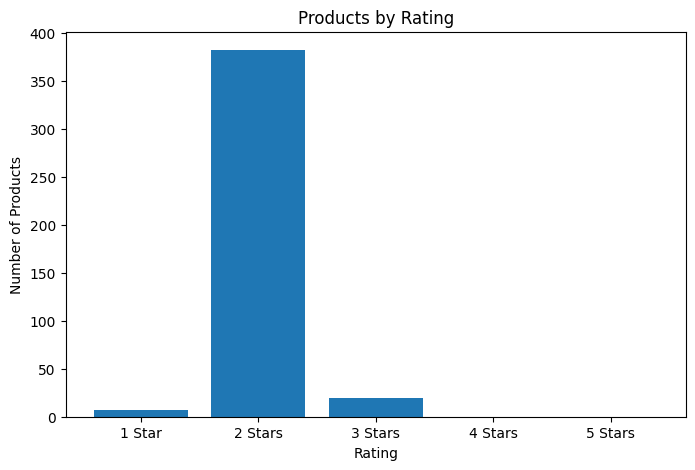

Interpretation:
Shows where most products fall on the rating scale.


In [32]:
# Group products by rating

rating_groups = pd.cut(
    df["rating"],
    bins=[0, 1, 2, 3, 4, 5],
    labels=[
        "1 Star",
        "2 Stars",
        "3 Stars",
        "4 Stars",
        "5 Stars"
    ],
    include_lowest=True
)

rating_count = rating_groups.value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    rating_count.index.astype(str),
    rating_count.values
)

plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.title("Products by Rating")

plt.show()

print("Interpretation:")
print("Shows where most products fall on the rating scale.")

# SQL Analysis



* Saves the cleaned dataset as a CSV file for reuse in other tools.
* Loads the data into SQLite and answers business questions using SQL.

In [33]:
file_name = "shopclues_mens_clothing_400plus.csv"

df.to_csv(
    file_name,
    index=False
)

print("CSV saved successfully!")
print("File:", file_name)

CSV saved successfully!
File: shopclues_mens_clothing_400plus.csv


#### Database Setup



* Loads the cleaned DataFrame into an in-memory SQLite table named `products`.

In [34]:
connection = sqlite3.connect(":memory:")

df.to_sql(
    "products",
    connection,
    index=False,
    if_exists="replace"
)

print("Data loaded into SQL table: products")

Data loaded into SQL table: products


#### Product Count

In [35]:
query = """
SELECT COUNT(*) AS total_products
FROM products;
"""

pd.read_sql(query, connection)

,total_products
0,408


* Shows the total number of products available in the dataset.
* Helps understand the overall product range.

#### Average Price

In [36]:
query = """
SELECT ROUND(AVG(price), 2) AS average_price
FROM products;
"""

pd.read_sql(query, connection)

,average_price
0,888.85


* Shows the general price level across the product range.

#### Top Expensive Products

In [37]:
query = """
SELECT product_name, price, rating
FROM products
ORDER BY price DESC
LIMIT 10;
"""

pd.read_sql(query, connection)

,product_name,price,rating
0,Regular Fit Blue Jeans,1899.0,1.822414
1,kurta,1699.0,1.822414
2,PrintCultr PrintCultr Men Printed Single Breas...,1249.0,1.822414
3,PrintCultr Solid Mandarin Festive & Wedding Me...,1249.0,1.822414
4,PrintCultr Single Breasted Festive & Wedding M...,1249.0,1.822414
5,PrintCultr PrintCultr Men Solid Single Breaste...,1249.0,1.822414
6,PrintCultr PrintCultr Men Printed Single Breas...,1249.0,1.822414
7,PrintCultr PrintCultr Men Solid Single Breaste...,1249.0,1.822414
8,PrintCultr PrintCultr Men Solid Single Breaste...,1249.0,1.822414
9,PrintCultr PrintCultr Men Solid Single Breaste...,1249.0,1.822414


* Identifies the highest-priced products, useful for spotting premium items.

#### Top Rated Products

In [38]:
query = """
SELECT product_name, rating, price
FROM products
ORDER BY rating DESC
LIMIT 10;
"""

pd.read_sql(query, connection)

,product_name,rating,price
0,Vida Loca Cotton Designer Shirt,2.59,599.0
1,PrintCultr Men Regular Fit Solid Curved Collar...,2.45,219.0
2,Vida Loca Cotton Designer Shirt,2.45,649.0
3,PrintCultr PLUS Plus Size Men Regular Fit Solid,2.45,239.0
4,29K Blue Cotton Fleece Printed Sweatshirt (FDMSWT,2.45,189.0
5,PrintCultr PLUS Plus Size Men Regular Fit Solid,2.38,399.0
6,PrintCultr Men Regular Fit Solid Casual Shirt ...,2.38,399.0
7,29K Navy Blue Cotton Fleece Printed Sweatshirt (F,2.31,169.0
8,PrintCultr Men Dhoti & Kurta Set (Black),2.31,455.0
9,Vida Loca Green Color Cotton Designer Shirt,2.31,649.0


* Finds the highest-rated products in the dataset.

#### Price by Rating

In [39]:
query = """
SELECT
    ROUND(rating, 1) AS rating,
    ROUND(AVG(price), 2) AS average_price,
    COUNT(*) AS product_count
FROM products
GROUP BY ROUND(rating, 1)
ORDER BY rating;
"""

pd.read_sql(query, connection)

,rating,average_price,product_count
0,0.7,674.71,7
1,1.1,279.00,1
2,1.4,889.00,1
3,1.8,922.08,379
4,1.9,693.00,1
5,2.0,254.00,2
6,2.1,249.00,2
7,2.2,326.50,4
8,2.3,398.00,4
9,2.4,399.00,2


* Compares average price across rating groups.

#### Above-Average Discounts

In [40]:
query = """
SELECT product_name, price, discount_percent
FROM products
WHERE discount_percent > (
    SELECT AVG(discount_percent)
    FROM products
)
ORDER BY discount_percent DESC;
"""

pd.read_sql(query, connection).head(10)

,product_name,price,discount_percent
0,PrintCulture Men Solid Black Cotton Blend Nehr...,619.0,89.0
1,PrintCulture Men Solid Black Cotton Blend Nehr...,619.0,89.0
2,PrintCulture Men Self Design Multicolor Cotton...,619.0,89.0
3,PrintCulture Men Solid Black Cotton Blend Nehr...,619.0,89.0
4,PrintCulture Men Self Design Brown Cotton Blen...,619.0,89.0
5,PrintCulture Men Self Design Light Blue Cotton...,619.0,89.0
6,PrintCulture Men Floral Red Cotton Blend Nehru...,619.0,89.0
7,PrintCulture Men Printed White Cotton Blend Ne...,619.0,89.0
8,PrintCulture Men Floral Red Cotton Blend Nehru...,619.0,89.0
9,PrintCulture Men Solid Black Cotton Blend Nehr...,619.0,89.0


* Finds products with stronger-than-average promotions.

#### Products Above 4 Stars

In [41]:
query = """
SELECT product_name, rating, price
FROM products
WHERE rating >= 2
ORDER BY rating DESC, price ASC;
"""

pd.read_sql(query, connection).head(20)

,product_name,rating,price
0,Vida Loca Cotton Designer Shirt,2.59,599.0
1,29K Blue Cotton Fleece Printed Sweatshirt (FDMSWT,2.45,189.0
2,PrintCultr Men Regular Fit Solid Curved Collar...,2.45,219.0
3,PrintCultr PLUS Plus Size Men Regular Fit Solid,2.45,239.0
4,Vida Loca Cotton Designer Shirt,2.45,649.0
5,PrintCultr PLUS Plus Size Men Regular Fit Solid,2.38,399.0
6,PrintCultr Men Regular Fit Solid Casual Shirt ...,2.38,399.0
7,29K Navy Blue Cotton Fleece Printed Sweatshirt (F,2.31,169.0
8,Baleshwar Men Blue Solid Slim Fit Casual Shirt,2.31,319.0
9,PrintCultr Men Dhoti & Kurta Set (Black),2.31,455.0


* Lists highly rated products, sorted from cheapest to most expensive.

#### Best Value Products



* Combines rating, discount and price thresholds to surface products with a strong price-to-quality mix.

In [42]:
query = """
SELECT product_name, price, rating, discount_percent
FROM products
WHERE rating >= 2
  AND discount_percent >= (
      SELECT AVG(discount_percent)
      FROM products
  )
  AND price <= (
      SELECT AVG(price)
      FROM products
  )
ORDER BY rating DESC, discount_percent DESC;
"""

pd.read_sql(query, connection).head(20)

,product_name,price,rating,discount_percent
0,Vida Loca Cotton Designer Shirt,599.0,2.59,76.0
1,PrintCultr Men Regular Fit Solid Curved Collar...,219.0,2.45,85.0
2,PrintCultr PLUS Plus Size Men Regular Fit Solid,239.0,2.45,84.0
3,29K Blue Cotton Fleece Printed Sweatshirt (FDMSWT,189.0,2.45,81.0
4,29K Navy Blue Cotton Fleece Printed Sweatshirt (F,169.0,2.31,83.0
5,PrintCultr Men Dhoti & Kurta Set (Black),455.0,2.31,81.0
6,Baleshwar Men Blue Solid Slim Fit Casual Shirt,319.0,2.31,75.0
7,PrintCultr Men Kurta and Pyjama Set (White),409.0,2.24,83.0
8,Baleshwar Men White Solid Formal Shirt (Pack of,259.0,2.24,76.0
9,Stylish Unisex Design Printed Hooded Sweatshir...,159.0,2.10,86.0


* Average price gives a sense of the overall price level.
* Top-rated and top-expensive queries separate premium from popular products.
* Average price by rating shows how price and customer rating relate.
* Above-average discount and best-value queries highlight products worth promoting.

# Validation



* Runs final checks on ratings and overall data quality before concluding the project.

#### Rating Validation

In [43]:
print("Minimum rating:", df["rating"].min())
print("Maximum rating:", df["rating"].max())
print("Average rating:", round(df["rating"].mean(), 2))
print("Missing ratings:", df["rating"].isna().sum())

if df["rating"].max() <= 5:
    print("Rating column looks correct.")
else:
    print("Check the rating extraction.")

Minimum rating: 0.7
Maximum rating: 2.59
Average rating: 1.82
Missing ratings: 0
Rating column looks correct.


#### Final Validation



* Confirms the total product count, unique product IDs, and absence of missing names or prices.

In [44]:
print("========== FINAL CHECK ==========")

print("Total products:", len(df))

print(
    "Unique product IDs:",
    df["product_id"].nunique()
)

print(
    "Duplicate product IDs:",
    df["product_id"].duplicated().sum()
)

print(
    "Missing product names:",
    df["product_name"].isna().sum()
)

print(
    "Missing prices:",
    df["price"].isna().sum()
)

print("\nFinal columns:")
print(df.columns.tolist())

========== FINAL CHECK ==========
Total products: 408
Unique product IDs: 408
Duplicate product IDs: 0
Missing product names: 0
Missing prices: 0

Final columns:
['product_id', 'product_name', 'price_raw', 'original_price_raw', 'discount_raw', 'rating', 'shipping', 'product_url', 'image_url', 'price', 'original_price', 'discount_percent']


* Confirms the dataset has no duplicate product IDs and no missing product names or prices.
* Confirms all final columns are present, marking the dataset ready for analysis and reporting.

# Business Recommendations



* **Pricing strategy:** Prices are concentrated between ₹159 and ₹1,899, with an average of ₹888.85 and a median of ₹899 — the market is centered on affordable-to-mid-range menswear. Assortment and marketing should keep this range as the core focus.
* **Discount strategy:** Discounts as high as 89% appear on select products (e.g. Nehru jackets around ₹619). These can anchor flash sales or clearance campaigns to drive traffic.
* **Premium products:** Items such as the Regular Fit Blue Jeans (₹1,899) and a kurta (₹1,699) sit well above the average price and can be positioned as premium or festive-wear options.
* **Value-for-money products:** Products meeting the best-value criteria (above-average discount, at or below average price) are strong candidates for "Best Deal" or "Recommended" badges on the storefront.
* **Shipping/promotion strategy:** The large majority of products (354 of 408) offer free shipping. The remaining products without free shipping could be prioritized for shipping-cost promotions to stay competitive.
* **Rating data quality:** Most product cards did not expose a rating value, so rating-based insights should be treated as directional rather than conclusive. Improving on-page rating visibility would strengthen future analysis.

# Key Business Insights



* 408 unique products were collected with no duplicate IDs or missing names/prices → the dataset is reliable for downstream analysis.
* Average price (₹888.85) is close to the median (₹899) → pricing is fairly evenly distributed without extreme skew.
* Prices range from ₹159 to ₹1,899 → the catalog spans budget to premium menswear, supporting a tiered pricing strategy.
* Discounts go as high as 89% on specific products → these can be used as headline offers to attract price-sensitive shoppers.
* 354 of 408 products (about 87%) offer free shipping → free shipping is a strong, catalog-wide selling point.
* Rating values were missing for most products (379 of 408 before filling) → rating-based conclusions are less reliable and rating capture should be improved at the source.
* A defined "best value" segment exists (above-average discount, at/below-average price) → these products are ready-made candidates for promotional placement.

# <font size=6 color='skyblue'>Thank You!</font>
___